In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
)
from sklearn.calibration import CalibrationDisplay
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# 1. Load your clean dataset
df = pd.read_csv('../../data/cleaned/smart_travel_dataset_cleaned.csv')
print(f'Raw shape: {df.shape}')

# 2. Prevent Data Leakage: Drop geographic identifiers
# If the model sees city names or coordinates, it memorizes instead of learning patterns.
columns_to_drop = ['city', 'country', 'lat', 'lng']
df_model = df.drop(columns=columns_to_drop).copy()

print(f'Working shape (no leakage columns): {df_model.shape}')
print(f'Features available for modeling: {list(df_model.columns)}')

# 3. Separate Features (X) and Target (y)
X = df_model.drop(columns=['Travel_Style'])
y = df_model['Travel_Style']

print(f'\nTarget distribution:\n{y.value_counts()}')

Raw shape: (108, 18)
Working shape (no leakage columns): (108, 14)
Features available for modeling: ['Cost of Living Index', 'Groceries Index', 'Restaurant Price Index', 'Local Purchasing Power Index', 'Temp_DecJanFeb', 'Temp_MarAprMay', 'Temp_JunJulAug', 'Temp_SepOctNov', 'Temp_YearAvg', 'Temp_Variance', 'Tourist_Cost_Score', 'Dining_Out_Premium', 'City_Scale', 'Travel_Style']

Target distribution:
Travel_Style
Culture       26
Adventure     18
Family        17
Relaxation    16
Luxury        16
Budget        15
Name: count, dtype: int64


In [3]:
# 1. Identify feature types for the pipeline
categorical_cols = ['City_Scale']
# All other columns in X are numerical
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# 2. Build the Preprocessor (The first step of our Scikit-Learn Pipeline)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 3. Setup Stratified K-Fold Cross Validation
# 5 splits means it will train on ~86 rows and test on ~22 rows, 5 separate times.
# We use a fixed random_state to satisfy the "Fix your seeds" requirement.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nPreprocessor and Cross-Validation strategy successfully defined!")

Numerical features (12): ['Cost of Living Index', 'Groceries Index', 'Restaurant Price Index', 'Local Purchasing Power Index', 'Temp_DecJanFeb', 'Temp_MarAprMay', 'Temp_JunJulAug', 'Temp_SepOctNov', 'Temp_YearAvg', 'Temp_Variance', 'Tourist_Cost_Score', 'Dining_Out_Premium']
Categorical features (1): ['City_Scale']

Preprocessor and Cross-Validation strategy successfully defined!


Graph successfully saved to: ../../graph/ml_target_distribution.png


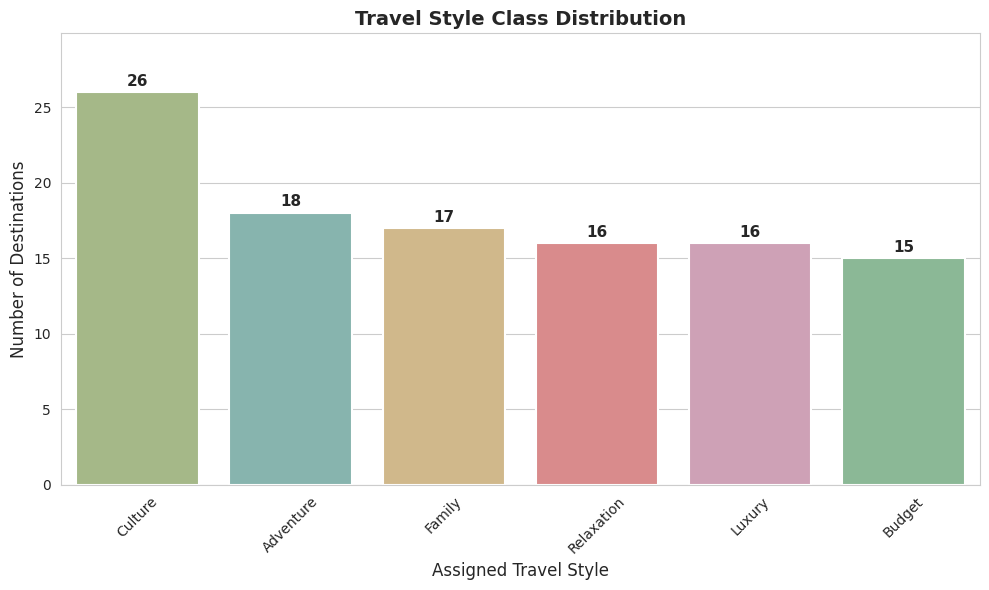

In [4]:
import os

# Ensure the graph directory exists based on your repo structure
os.makedirs('../../graph', exist_ok=True)

plt.figure(figsize=(10, 6))

# Get the counts for your 6 travel styles
counts = y.value_counts()

# Earthy, clean palette for the visualization
custom_palette = ['#a7c080', '#7fbbb3', '#dbbc7f', '#e67e80', '#d699b6', '#83c092']

ax = sns.barplot(x=counts.index, y=counts.values, palette=custom_palette, edgecolor='white', linewidth=1.5)

# Add exact counts on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 8), 
                textcoords = 'offset points',
                fontweight='bold', fontsize=11)

plt.title('Travel Style Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Assigned Travel Style', fontsize=12)
plt.ylabel('Number of Destinations', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()

# Save the graph to your specified folder
save_path = '../../graph/ml_target_distribution.png'
plt.savefig(save_path, dpi=300)
print(f"Graph successfully saved to: {save_path}")

plt.show()

In [5]:
import os
from sklearn.model_selection import cross_validate, cross_val_predict
import pandas as pd

# 1. Define the three classifiers (Requirement: "Compare at least three classifiers")
# We use random_state=42 to fix the seeds (Requirement: "Fix your seeds")
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'HistGradient Boosting': HistGradientBoostingClassifier(random_state=42)
}

experiment_logs = []

print("Starting 5-Fold Cross Validation...\n")

# 2. Run the K-Fold comparison
for name, clf in models.items():
    # Build the strict pipeline linking our preprocessor directly to the model
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # Evaluate using the exact metrics requested by the rubric
    scores = cross_validate(model_pipeline, X, y, cv=cv, 
                            scoring=['accuracy', 'f1_macro'])
    
    acc_mean = scores['test_accuracy'].mean()
    acc_std = scores['test_accuracy'].std()
    f1_mean = scores['test_f1_macro'].mean()
    f1_std = scores['test_f1_macro'].std()
    
    print(f"=== {name} ===")
    print(f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"Macro F1: {f1_mean:.4f} ± {f1_std:.4f}\n")
    
    # Save the data for the CSV
    experiment_logs.append({
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model': name,
        'params': 'default_baseline',
        'accuracy_mean': round(acc_mean, 4),
        'accuracy_std': round(acc_std, 4),
        'f1_macro_mean': round(f1_mean, 4),
        'f1_macro_std': round(f1_std, 4)
    })

# 3. Save to results.csv (Requirement: "Track every experiment in a results.csv")
os.makedirs('../../data/ml', exist_ok=True)
results_path = '../../data/ml/results.csv'
results_df = pd.DataFrame(experiment_logs)

# Append if exists, write new if it doesn't
if os.path.exists(results_path):
    results_df.to_csv(results_path, mode='a', index=False, header=False)
else:
    results_df.to_csv(results_path, index=False)

print(f"Baseline experiments logged to: {results_path}")

Starting 5-Fold Cross Validation...

=== Logistic Regression ===
Accuracy: 0.7948 ± 0.1148
Macro F1: 0.7716 ± 0.1183

=== Random Forest ===
Accuracy: 0.8978 ± 0.0686
Macro F1: 0.8864 ± 0.0748

=== HistGradient Boosting ===
Accuracy: 0.9169 ± 0.0602
Macro F1: 0.9039 ± 0.0643

Baseline experiments logged to: ../../data/ml/results.csv


In [6]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

print("Generating per-class metrics for the winning model (HistGradient Boosting)...\n")

# 1. Rebuild the winning pipeline
winning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

# 2. Generate out-of-fold predictions for the entire dataset
# This ensures every prediction was made by a model that had NEVER seen that specific row before
y_pred_cv = cross_val_predict(winning_pipeline, X, y, cv=cv)

# 3. Print the detailed classification report
print("=== Cross-Validated Classification Report ===")
report = classification_report(y, y_pred_cv)
print(report)

Generating per-class metrics for the winning model (HistGradient Boosting)...

=== Cross-Validated Classification Report ===
              precision    recall  f1-score   support

   Adventure       0.82      0.78      0.80        18
      Budget       0.93      0.93      0.93        15
     Culture       1.00      1.00      1.00        26
      Family       0.83      0.88      0.86        17
      Luxury       0.89      1.00      0.94        16
  Relaxation       1.00      0.88      0.93        16

    accuracy                           0.92       108
   macro avg       0.91      0.91      0.91       108
weighted avg       0.92      0.92      0.92       108



Model comparison graph successfully saved to: ../../graph/model_comparison_metrics.png


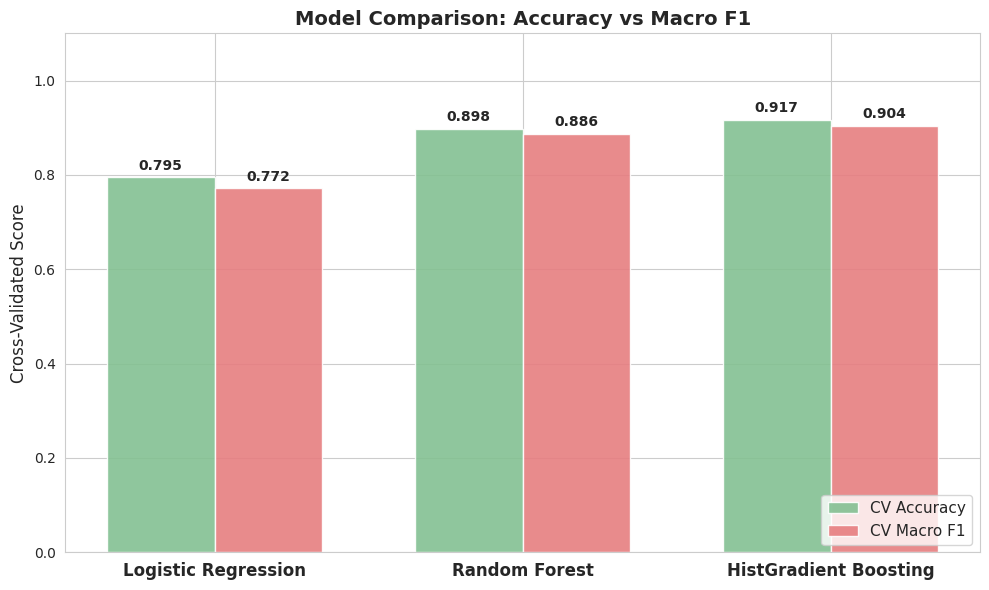

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the results we saved earlier
results_df = pd.read_csv('../../data/ml/results.csv')

# If you ran the loop multiple times, keep only the latest run for each model
results_df = results_df.drop_duplicates(subset=['model'], keep='last')

# 2. Setup the plot
metrics = ['accuracy_mean', 'f1_macro_mean']
labels = ['CV Accuracy', 'CV Macro F1']
palette = ['#83c092', '#e67e80'] # Clean Everforest greens and reds

x = np.arange(len(results_df['model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot the bars
for i, metric in enumerate(metrics):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, results_df[metric], width, 
                  label=labels[i], color=palette[i], edgecolor='white', alpha=0.9)
    
    # Add the text labels on top of the bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
                f'{yval:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Formatting
ax.set_xticks(x)
ax.set_xticklabels(results_df['model'], fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1) # Give room for the text labels
ax.set_ylabel('Cross-Validated Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy vs Macro F1', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()

# 5. Save the asset
save_path = '../../graph/model_comparison_metrics.png'
plt.savefig(save_path, dpi=300)
print(f"Model comparison graph successfully saved to: {save_path}")

plt.show()

In [8]:
import joblib
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning for HistGradient Boosting...\n")

# 1. Define the search space
# We prefix with 'classifier__' because the model is inside our Scikit-Learn Pipeline
param_grid = {
    'classifier__learning_rate': [0.05, 0.1, 0.2],  # How fast the model learns
    'classifier__max_iter': [100, 150, 200],        # Number of trees
    'classifier__l2_regularization': [0.0, 0.5, 1.0] # Penalty to prevent overfitting
}

# 2. Setup the Grid Search
# We optimize for 'f1_macro' to stay consistent with our imbalance handling
grid_search = GridSearchCV(
    estimator=winning_pipeline, 
    param_grid=param_grid,
    cv=cv,                 # Our 5-fold cross validation strategy
    scoring='f1_macro',    
    n_jobs=-1,             # Use all available CPU cores
    verbose=1
)

# 3. Execute the search across the entire dataset
grid_search.fit(X, y)

print("\n=== Tuning Results ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validated Macro F1: {grid_search.best_score_:.4f}\n")

# 4. Save the absolute best pipeline (Preprocessor + Tuned Classifier)
model_path = '../../data/ml/travel_style_classifier.joblib'
joblib.dump(grid_search.best_estimator_, model_path)

print(f"✅ Tuned model successfully saved to: {model_path}")
print("This is the exact file your FastAPI backend will load!")

Starting Hyperparameter Tuning for HistGradient Boosting...

Fitting 5 folds for each of 27 candidates, totalling 135 fits

=== Tuning Results ===
Best Parameters: {'classifier__l2_regularization': 0.0, 'classifier__learning_rate': 0.05, 'classifier__max_iter': 150}
Best Cross-Validated Macro F1: 0.9240

✅ Tuned model successfully saved to: ../../data/ml/travel_style_classifier.joblib
This is the exact file your FastAPI backend will load!


Computing permutation importance for the tuned HistGradient model...
(This shuffles each column one by one to see how much the F1 score drops.)

Feature importance graph successfully saved to: ../../graph/feature_importance.png


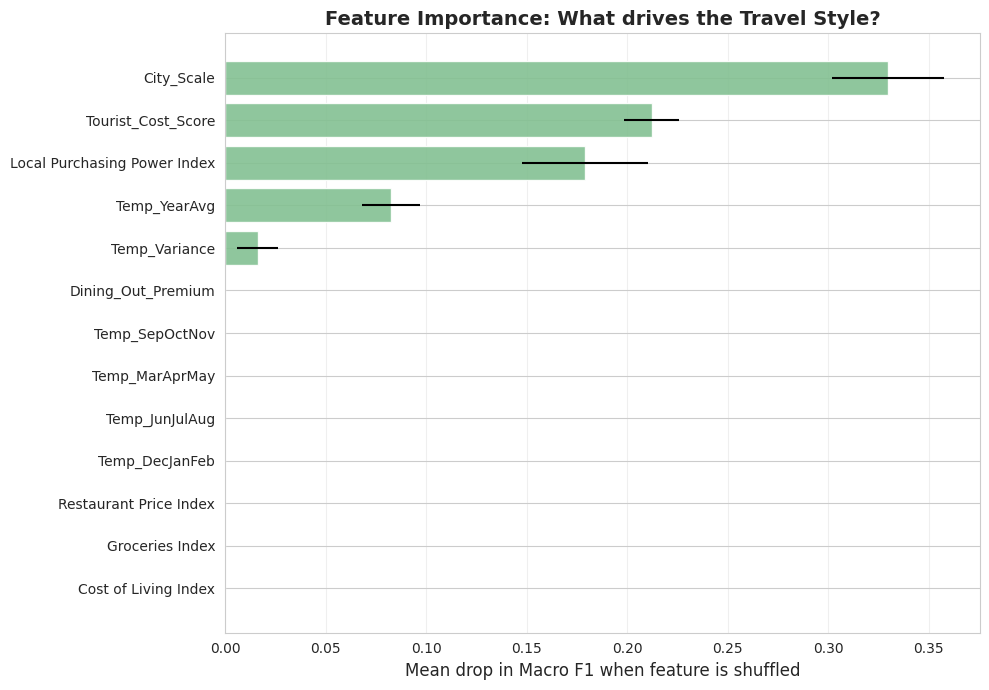


Top 3 defining features for Travel Style:
  City_Scale                     (Impact: 0.3297)
  Tourist_Cost_Score             (Impact: 0.2121)
  Local Purchasing Power Index   (Impact: 0.1792)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

print("Computing permutation importance for the tuned HistGradient model...")
print("(This shuffles each column one by one to see how much the F1 score drops.)\n")

# 1. Use the best estimator from our GridSearchCV (it has already been refitted on the full X, y)
best_model = grid_search.best_estimator_

# 2. Compute permutation importance using our target metric
# We use the full X, y here to see what the final production model actually learned
perm = permutation_importance(
    best_model, X, y, 
    scoring='f1_macro', n_repeats=5, random_state=42, n_jobs=-1
)

# 3. Extract and sort the results
importances = perm.importances_mean
stds = perm.importances_std
feat_labels = X.columns.to_numpy()

# Sort by importance (ascending for horizontal bar chart)
top_idx = np.argsort(importances)
top_lbl = feat_labels[top_idx]
top_val = importances[top_idx]
top_std = stds[top_idx]

# 4. Plot the results using the Everforest palette
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_lbl, top_val, xerr=top_std, color='#83c092', alpha=0.9, edgecolor='white')

ax.set_xlabel('Mean drop in Macro F1 when feature is shuffled', fontsize=12)
ax.set_title('Feature Importance: What drives the Travel Style?', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()

# 5. Save the asset for the README
save_path = '../../graph/feature_importance.png'
plt.savefig(save_path, dpi=300)
print(f"Feature importance graph successfully saved to: {save_path}")

plt.show()

# Print the top 3 drivers to the console
print('\nTop 3 defining features for Travel Style:')
for lbl, val in zip(top_lbl[::-1][:3], top_val[::-1][:3]):
    print(f'  {lbl:30s} (Impact: {val:.4f})')

Generating Confusion Matrix for the tuned HistGradient model...

Confusion matrix successfully saved to: ../../graph/confusion_matrix.png


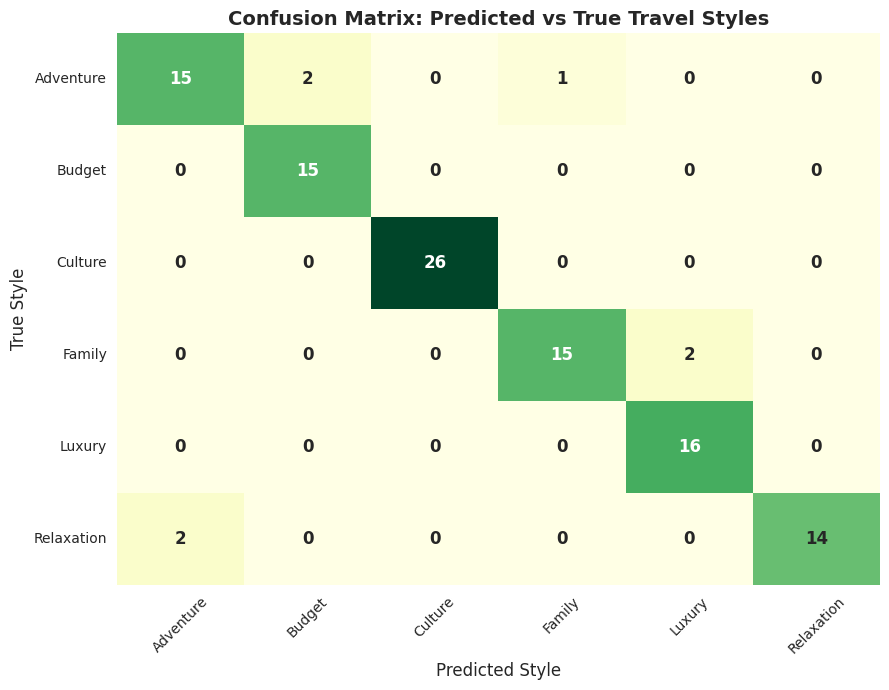

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

print("Generating Confusion Matrix for the tuned HistGradient model...\n")

# 1. Get cross-validated predictions for the entire dataset
# We use the best estimator from our grid search
y_pred_cv = cross_val_predict(grid_search.best_estimator_, X, y, cv=cv)

# 2. Extract the actual class names so the labels match
classes = grid_search.best_estimator_.classes_

# 3. Compute the matrix
cm = confusion_matrix(y, y_pred_cv, labels=classes)

# 4. Plotting
fig, ax = plt.subplots(figsize=(9, 7))

# Using 'YlGn' (Yellow-Green) to maintain a clean, earthy aesthetic
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlGn', ax=ax,
    xticklabels=classes, yticklabels=classes,
    cbar=False, annot_kws={'size': 12, 'fontweight': 'bold'}
)

ax.set_title('Confusion Matrix: Predicted vs True Travel Styles', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Style', fontsize=12)
ax.set_ylabel('True Style', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# 5. Save the asset for the README
save_path = '../../graph/confusion_matrix.png'
plt.savefig(save_path, dpi=300)
print(f"Confusion matrix successfully saved to: {save_path}")

plt.show()